In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/co2.csv')

In [5]:
# Basically, I copied the entire process from EDA01 to obtain the preds and y_train.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
import joblib
from sklearn.metrics import mean_absolute_error, r2_score

df = df.rename(columns={
    'Vehicle Class': 'Vehicle_type',
    'Engine Size(L)': 'Engine_Size_L',
    'Fuel Type': 'Fuel_Type',
    'Fuel Consumption Comb (L/100 km)': 'Fuel_Consumption_Comb_L_per_100_km',
    'CO2 Emissions(g/km)': 'CO2_Emissions_g_per_km'
})

features = [
    'Engine_Size_L', 'Cylinders', 'Transmission', 
    'Fuel_Type', 'Fuel_Consumption_Comb_L_per_100_km', 'Vehicle_type'
]
target = 'CO2_Emissions_g_per_km'

x = df[features]
y = df[target]



cat_features = ['Transmission', 'Fuel_Type', 'Vehicle_type']
num_features = ['Engine_Size_L', 'Cylinders', 'Fuel_Consumption_Comb_L_per_100_km']

preprocessor = ColumnTransformer(
    transformers = [
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


# Create pipeline to process and training
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Training model
model_pipeline.fit(X_train, y_train)

# (Optional) Evaluate regression metrics (RMSE, MAE)
preds = model_pipeline.predict(X_test)

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up a design for the chart
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "figure.figsize": (10, 6),
    "figure.dpi": 100,
    "axes.edgecolor": "#cccccc"
})

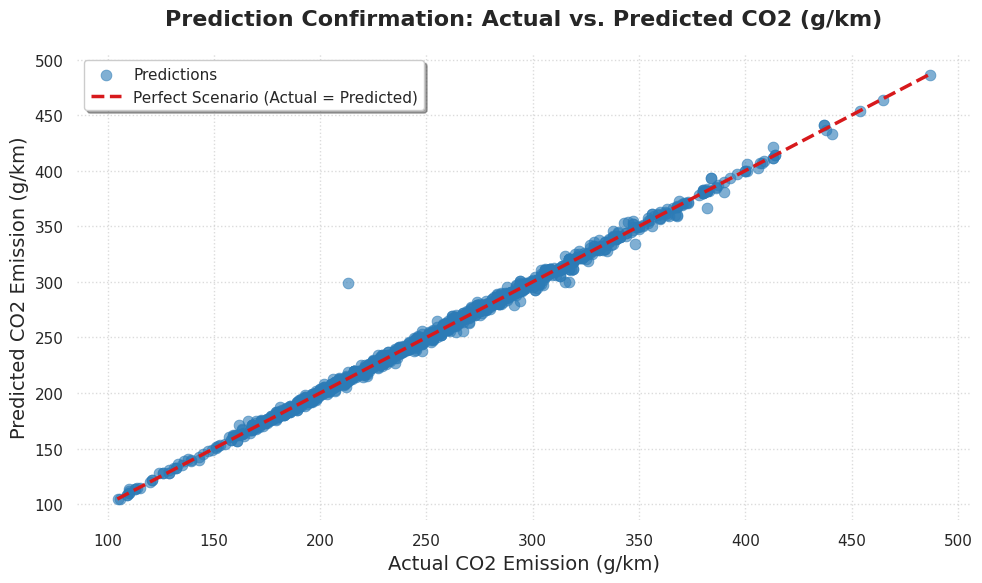

In [16]:
fig, ax = plt.subplots()

# Scatter plot: Actual (X) vs. Predicted (Y) values
sns.scatterplot(
    x=y_test, 
    y=preds, 
    alpha=0.6,          # Transparency to see overlapping points
    color="#2C7BB6",    # blue
    edgecolor=None, 
    s=60,               # Point size
    ax=ax,
    label="Predictions"
)
# Dashed red reference line (y = x)
# We use the minimum and maximum data values to draw the diagonal line
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
ax.plot(
    [min_val, max_val], 
    [min_val, max_val], 
    color="#D7191C",    # red
    linestyle="--", 
    linewidth=2.5, 
    label="Perfect Scenario (Actual = Predicted)"
)
# Texts and Labels
ax.set_title("Prediction Confirmation: Actual vs. Predicted CO2 (g/km)", pad=20)
ax.set_xlabel("Actual CO2 Emission (g/km)")
ax.set_ylabel("Predicted CO2 Emission (g/km)")
# Design improvements: removes extra borders
sns.despine(left=True, bottom=True)
ax.grid(True, linestyle=":", alpha=0.7)
# Add legend and adjust layout
ax.legend(frameon=True, loc="upper left", shadow=True)
# render
plt.tight_layout()
plt.show()

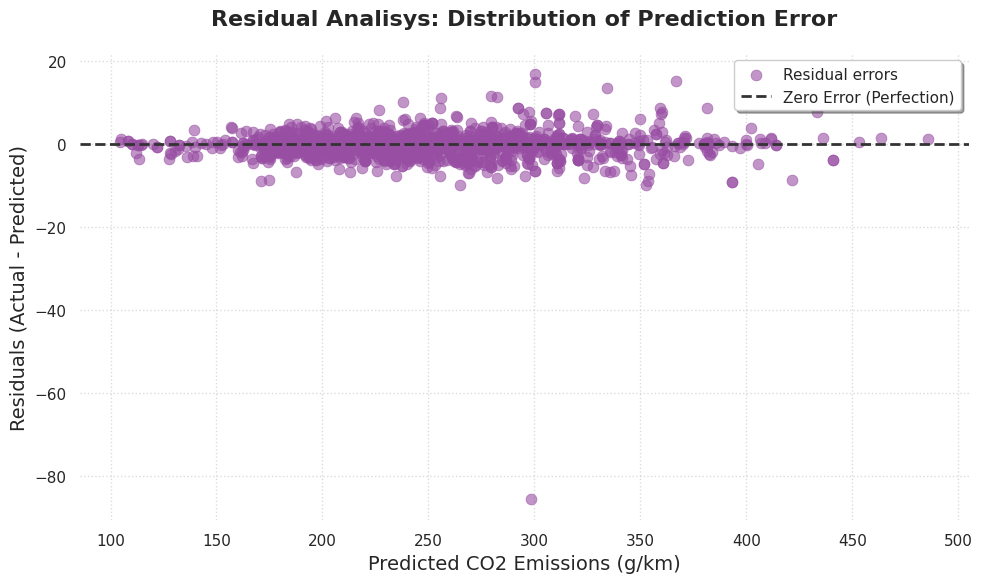

In [13]:
# 1. Calculating residuals (difference between actual and predicted)
residuos = y_test - preds

fig, ax = plt.subplots()

# 2. Scatter plot: Predictions (X) vs Residuals (Y)
sns.scatterplot(
    x=preds, 
    y=residuos, 
    alpha=0.6,          # Transparency to visualize density
    color="#984EA3",    # Sophisticated purple to contrast with previous plot
    edgecolor=None, 
    s=60, 
    ax=ax,
    label="Residual Errors"
)

# 3. Horizontal line indicating Zero Error (y = 0)
ax.axhline(
    y=0, 
    color="#333333",    # Dark gray for the reference line
    linestyle="--", 
    linewidth=2, 
    label="Zero Error (Perfection)"
)

# 4. Texts, Labels and Title
ax.set_title("Residual Analysis: Prediction Error Distribution", pad=20)
ax.set_xlabel("Predicted CO2 Emission (g/km)")
ax.set_ylabel("Residuals (Actual - Predicted)")

# 5. Design Improvements
sns.despine(left=True, bottom=True)
ax.grid(True, linestyle=":", alpha=0.7)

# Add legend
ax.legend(frameon=True, loc="best", shadow=True)

# Final render
plt.tight_layout()
plt.show()

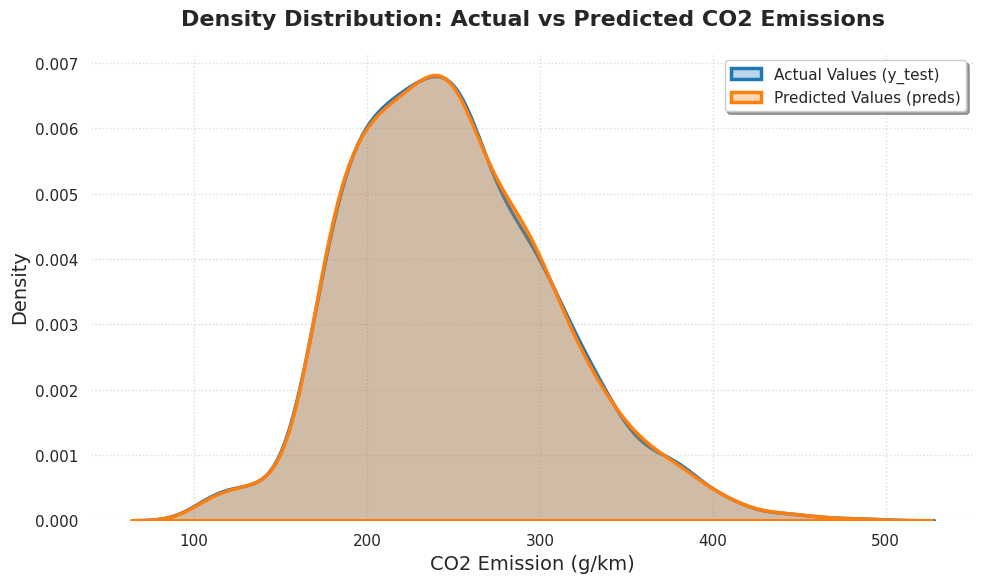

In [17]:
# Cell 4: Density Distribution Comparison (Actual vs Predicted Values)
fig, ax = plt.subplots()

# 1. Plot the distribution of ACTUAL values (y_test)
sns.kdeplot(
    x=y_test, 
    fill=True, 
    alpha=0.3,          
    color="#1F77B4",    # blue
    linewidth=2.5,
    label="Actual Values (y_test)",
    ax=ax
)

# 2. Plot the distribution of PREDICTED values (preds)
sns.kdeplot(
    x=preds, 
    fill=True, 
    alpha=0.3,          
    color="#FF7F0E",    # orange
    linewidth=2.5,
    label="Predicted Values (preds)",
    ax=ax
)

# 3. Texts, Labels and Title
ax.set_title("Density Distribution: Actual vs Predicted CO2 Emissions", pad=20)
ax.set_xlabel("CO2 Emission (g/km)")
ax.set_ylabel("Density")

sns.despine(left=True, bottom=True)
ax.grid(True, linestyle=":", alpha=0.7)

# legend
ax.legend(frameon=True, loc="upper right", shadow=True)

# render
plt.tight_layout()
plt.show()